In [21]:
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras
from keras.datasets import mnist

In [22]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

In [23]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

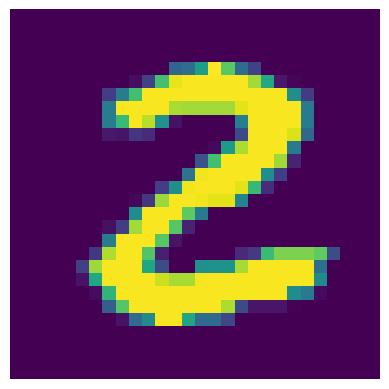

Label: 2


In [24]:
import numpy as np
import matplotlib.pyplot as plt
plt.imshow(X_train[25])
plt.axis("off")
plt.show()
print(f"Label: {y_train[25]}")

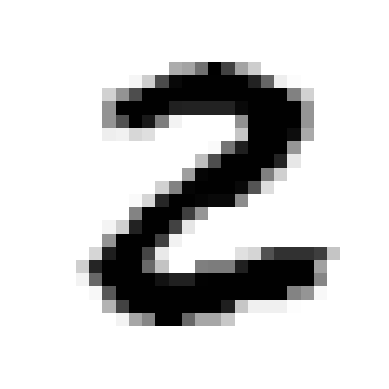

2


In [25]:
import matplotlib
digit=X_train[25]
digit_image=digit.reshape(28,28)
plt.imshow(digit_image,cmap=matplotlib.cm.binary,interpolation="nearest")
plt.axis("off")
plt.show()
print(y_train[25])

In [26]:
# Check unique labels in the dataset
np.unique(y_train), np.unique(y_test)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8))

In [27]:
# Count unique values in y_train (True/False for digit 2)
unique, counts = np.unique(y_train, return_counts=True)
print("Value counts for y_train:")
for value, count in zip(unique, counts):
    print(f"{value}: {count}")

Value counts for y_train:
0: 5923
1: 6742
2: 5958
3: 6131
4: 5842
5: 5421
6: 5918
7: 6265
8: 5851
9: 5949


## Data Analysis & Visualization

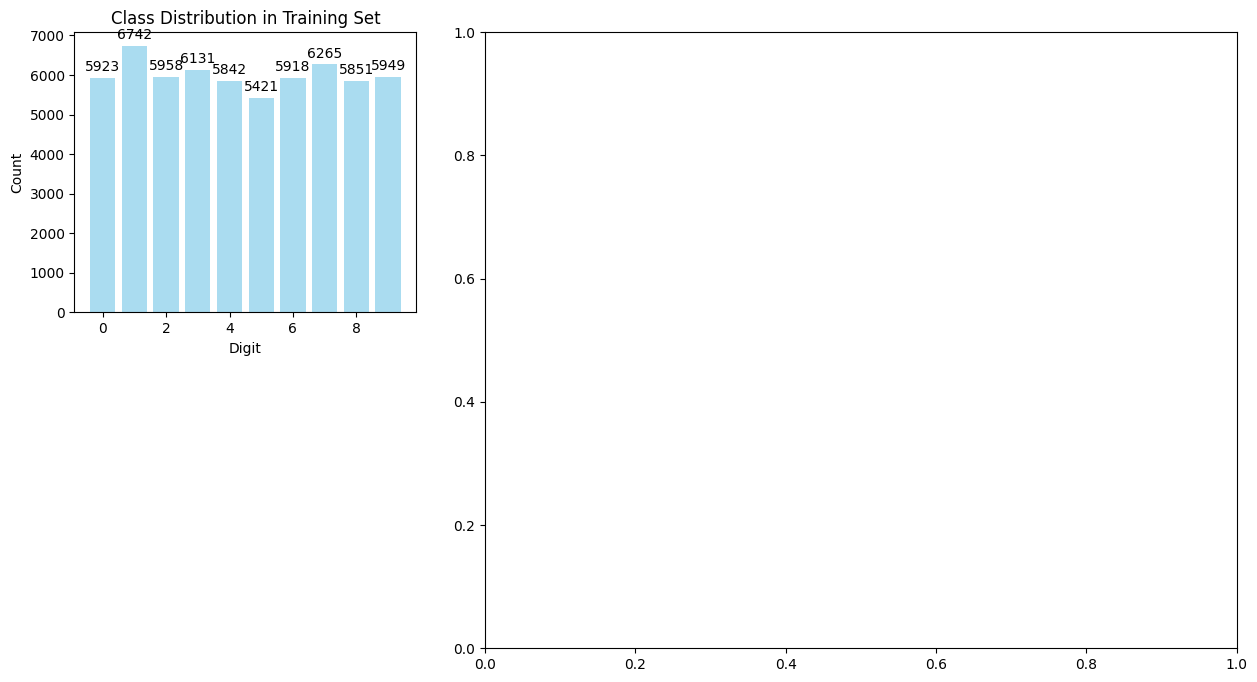

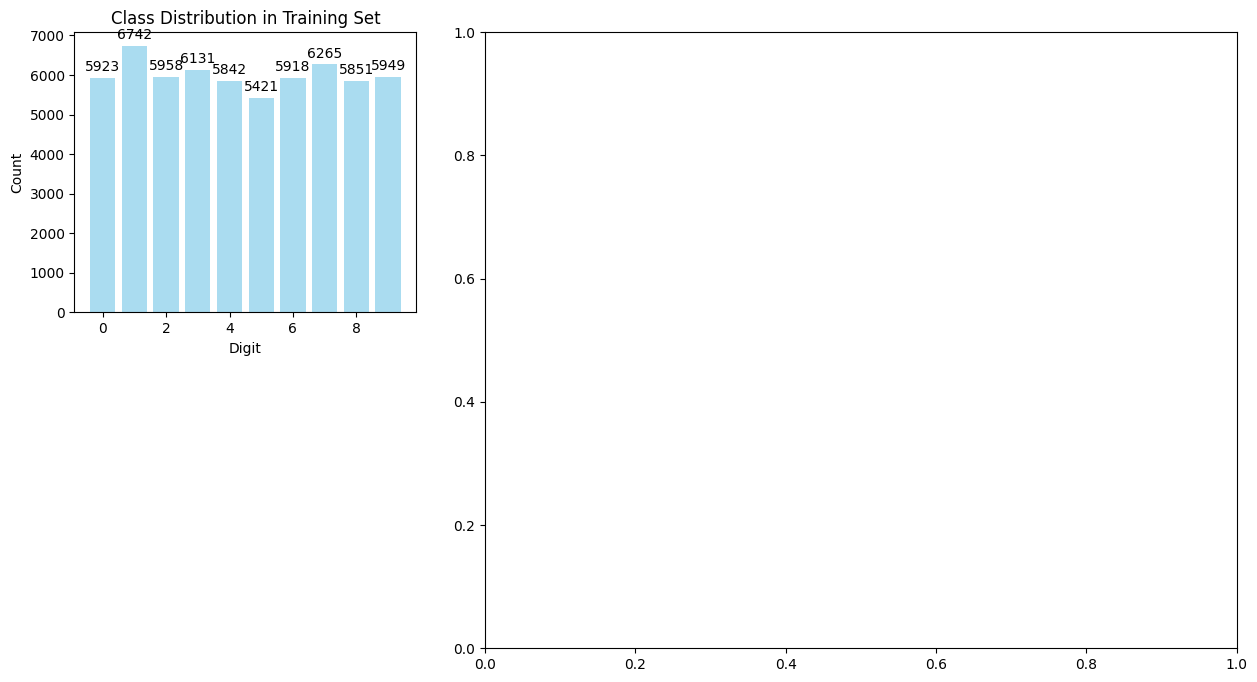

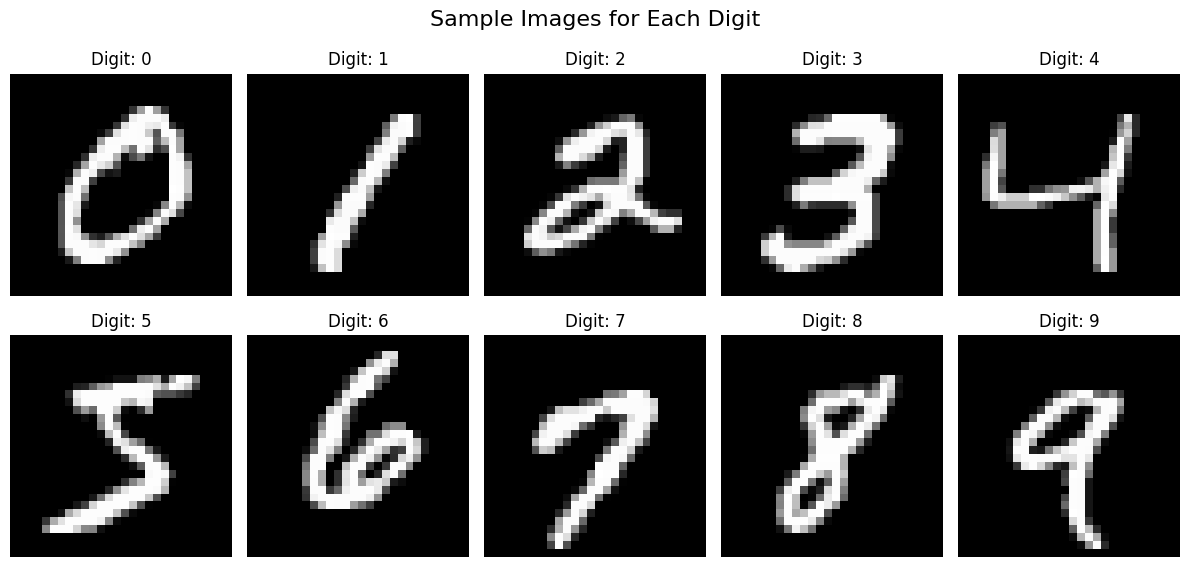

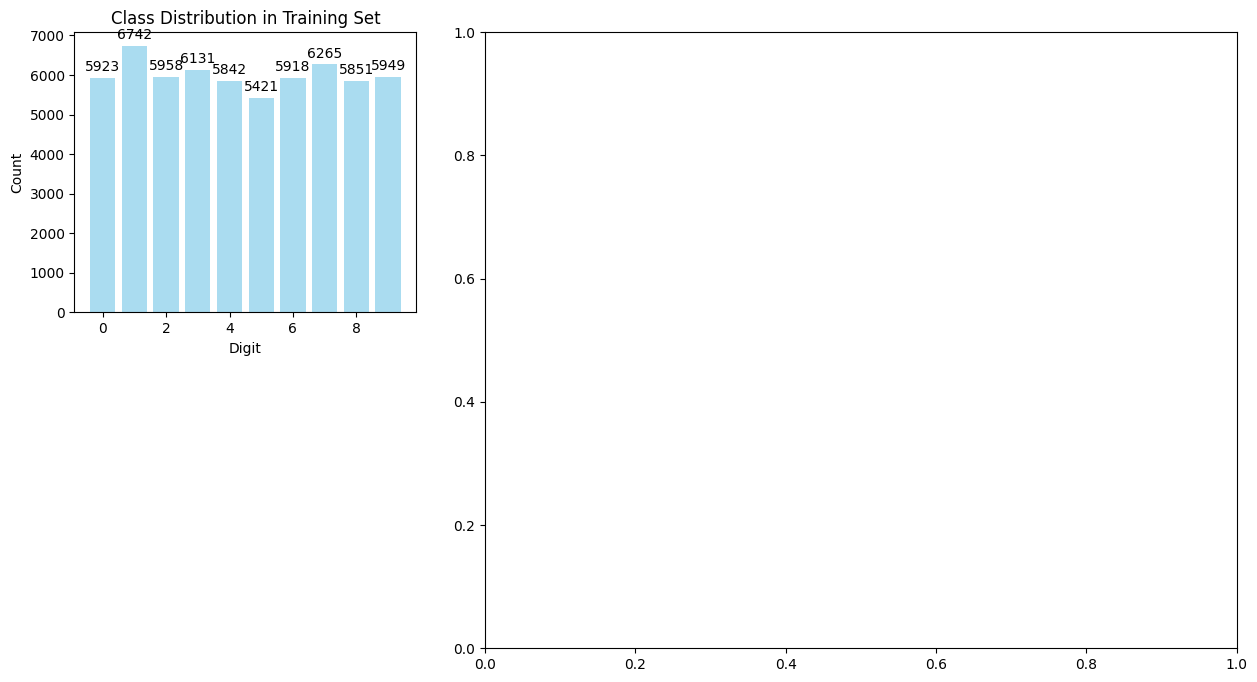

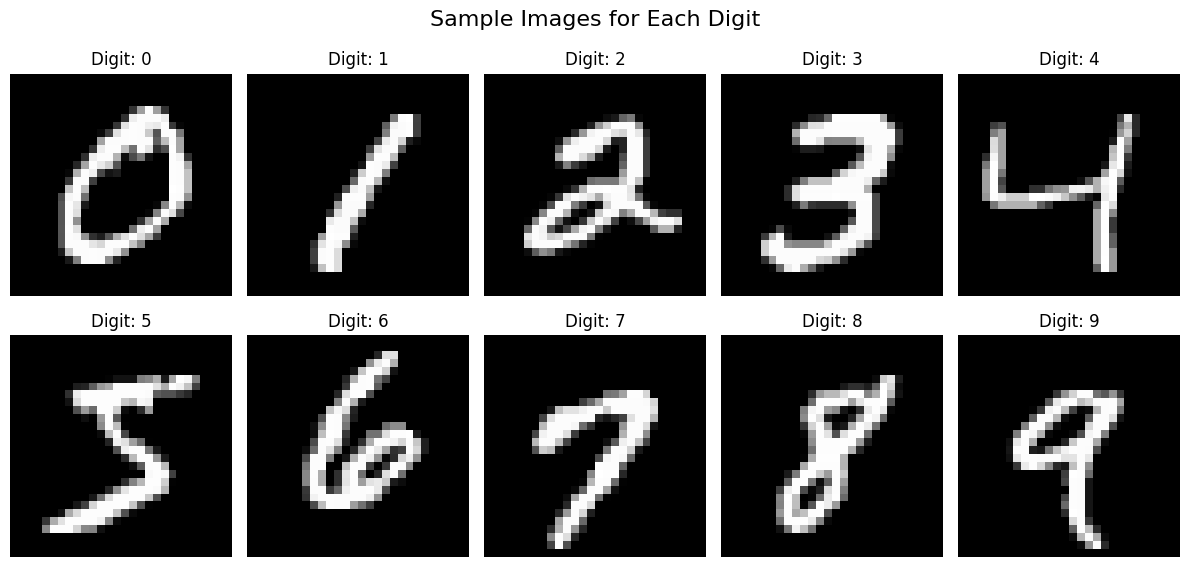

Dataset Statistics:
Training images: 60,000
Test images: 10,000
Image dimensions: 28x28
Pixel value range: 0.000 - 255.000
Mean pixel intensity: 33.318
Standard deviation: 78.567
Standard deviation: 78.567


In [28]:
# Enhanced data exploration
plt.figure(figsize=(15, 8))

# Show class distribution
plt.subplot(2, 3, 1)
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(unique, counts, color='skyblue', alpha=0.7)
plt.title('Class Distribution in Training Set')
plt.xlabel('Digit')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 100, str(v), ha='center', va='bottom')

# Show sample images for each digit
plt.subplot(2, 3, (2, 6))
fig2, axes = plt.subplots(2, 5, figsize=(12, 6))
fig2.suptitle('Sample Images for Each Digit', fontsize=16)

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y_train == digit)[0][0]
    row = digit // 5
    col = digit % 5
    axes[row, col].imshow(X_train[idx], cmap='gray')
    axes[row, col].set_title(f'Digit: {digit}')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Show pixel intensity statistics
print("Dataset Statistics:")
print(f"Training images: {X_train.shape[0]:,}")
print(f"Test images: {X_test.shape[0]:,}")
print(f"Image dimensions: {X_train.shape[1]}x{X_train.shape[2]}")
print(f"Pixel value range: {X_train.min():.3f} - {X_train.max():.3f}")
print(f"Mean pixel intensity: {X_train.mean():.3f}")
print(f"Standard deviation: {X_train.std():.3f}")

In [29]:
# Data preprocessing - normalize pixel values
X_train = X_train / 255
X_test = X_test / 255
X_train.shape


(60000, 28, 28)

In [30]:

model=keras.Sequential([
    keras.layers.Flatten(input_shape=[28,28]),
    keras.layers.Dense(120,activation="relu"),
    keras.layers.Dense(60,activation="relu"),
    keras.layers.Dense(10,activation="sigmoid")
])
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

c:\Users\narra\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Model Architecture & Training

In [ ]:
#history = model.fit(X_train,y_train,epochs=10)
#loss,accuracy=model.evaluate(X_test,y_test)
#print(accuracy)
#y_pred=model.predict(X_test)
#y_pred_labels=[np.argmax(i) for i in y_pred]



# Enhanced training with validation split and callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Add callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=0.0001,
    verbose=1
)

# Train with validation split
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate on test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")
print(f"Final Test Loss: {loss:.4f}")

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9968 - loss: 0.0091 - val_accuracy: 0.9978 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9968 - loss: 0.0091 - val_accuracy: 0.9978 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9982 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9993 - loss: 0.0028 - val_accuracy: 0.9982 - val_loss: 0.0060 - learning_rate: 0.0010
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9983 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9997 - loss: 0.0017 - val_accuracy: 0.9983 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9998 - loss: 0.0012 - 

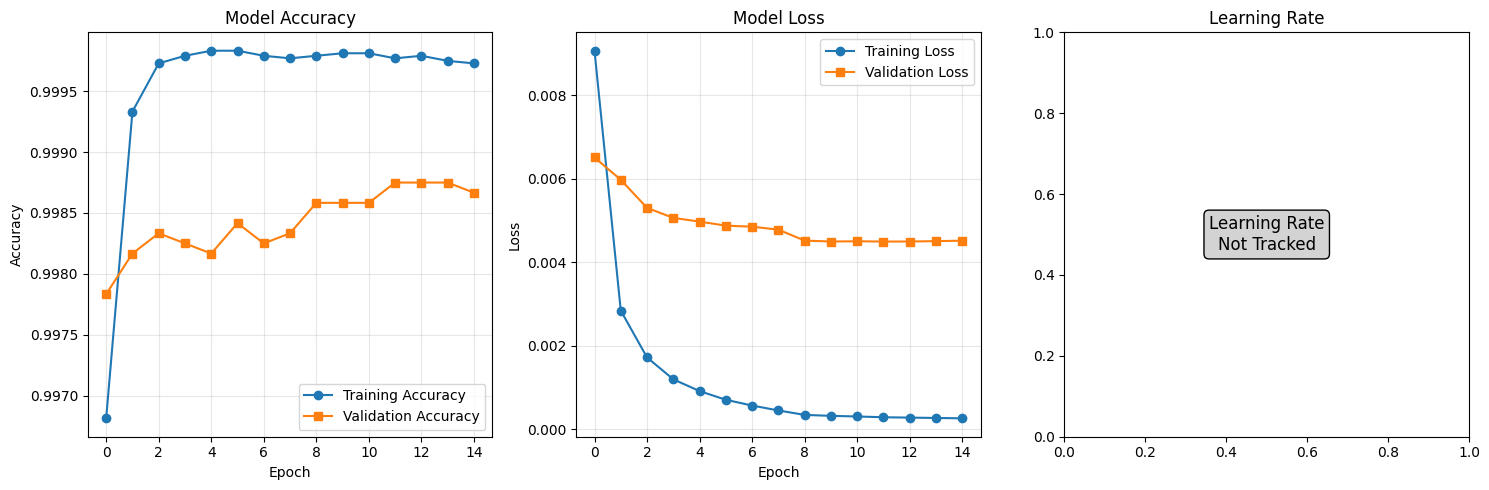

In [33]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot training & validation accuracy
plt.subplot(1, 3, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot training & validation loss
plt.subplot(1, 3, 2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot learning rate (if available)
plt.subplot(1, 3, 3)
if 'lr' in history.history:
    plt.plot(history.history['lr'], label='Learning Rate', marker='d')
    plt.title('Learning Rate Schedule')
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.text(0.5, 0.5, 'Learning Rate\nNot Tracked', 
             ha='center', va='center', transform=plt.gca().transAxes,
             fontsize=12, bbox=dict(boxstyle='round', facecolor='lightgray'))
    plt.title('Learning Rate')

plt.tight_layout()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


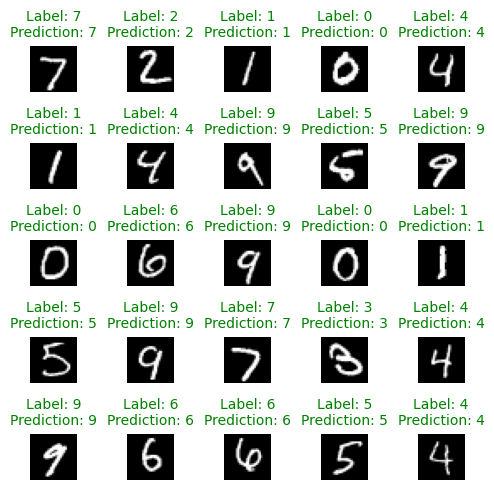

In [34]:
predctions=model.predict(X_test)
predictions=[np.argmax(i) for i in predctions]
plt.figure(figsize=(5, 5))
for i in range(25):
 plt.subplot(5, 5, i + 1)
 plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
 plt.axis('off')
 plt.title(f'Label: {y_test[i]}\nPrediction: {predictions[i]}', color='green' if y_test[i] == predictions[i] else 'red', fontsize=10) # Adjusted fontsize
plt.tight_layout() # Added to prevent overlapping titles
plt.show()

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       980
           1       1.00      0.98      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.95      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.94      0.98      0.96       892
           6       0.98      0.97      0.97       958
           7       0.98      0.95      0.97      1028
           8       0.96      0.97      0.96       974
           9       0.94      0.97      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



              precision    recall  f1-score   support

           0       0.99      0.97      0.98       980
           1       1.00      0.98      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.95      0.97      0.96      1010
           4       0.98      0.97      0.97       982
           5       0.94      0.98      0.96       892
           6       0.98      0.97      0.97       958
           7       0.98      0.95      0.97      1028
           8       0.96      0.97      0.96       974
           9       0.94      0.97      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



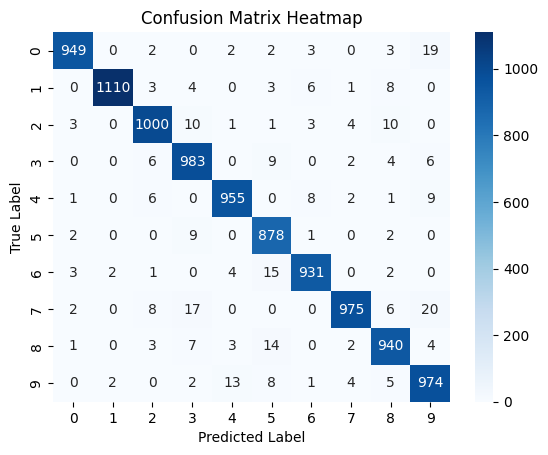

In [35]:

from sklearn.metrics import confusion_matrix,classification_report
cm=confusion_matrix(y_test,y_pred_labels)
cr=classification_report(y_test,y_pred_labels)
print(cr)
import seaborn as sns
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Model Evaluation & Analysis

Total misclassified: 187 out of 10000 (1.87%)


Total misclassified: 187 out of 10000 (1.87%)


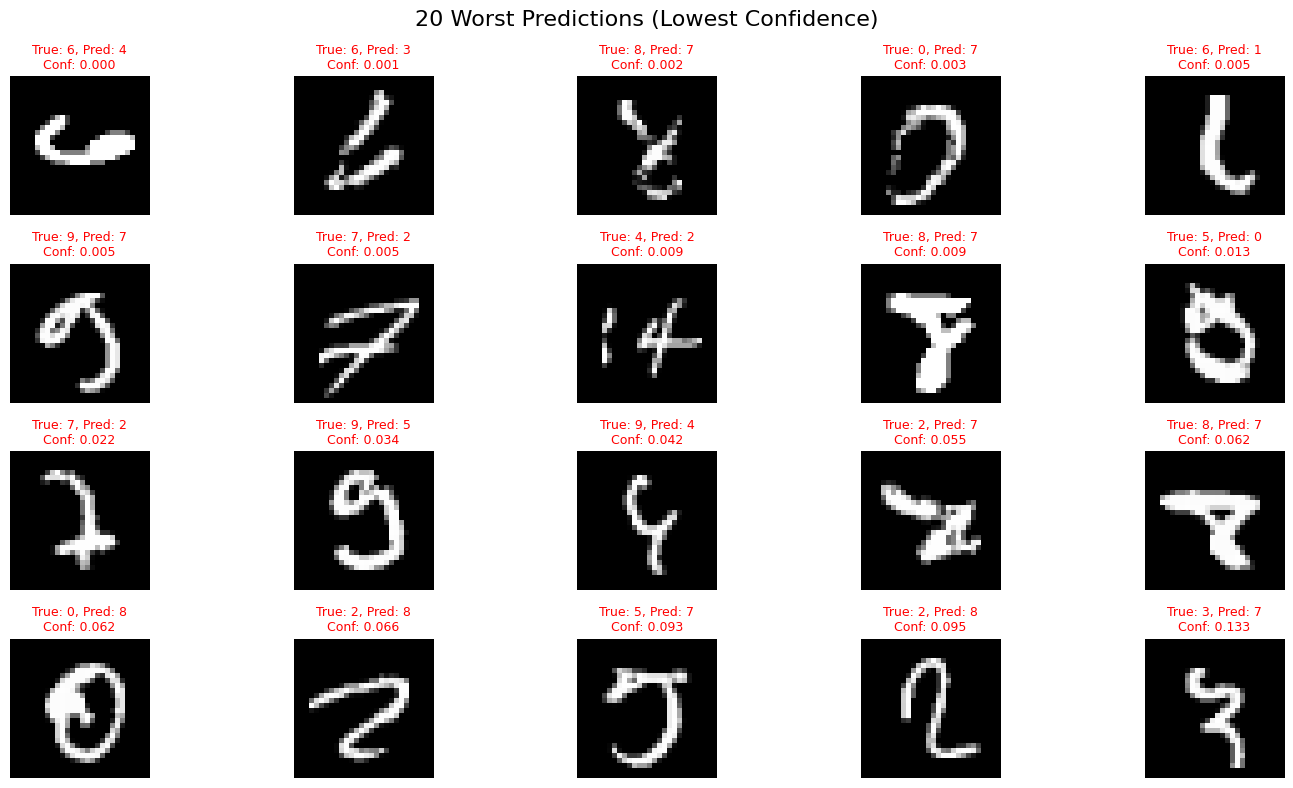

Total misclassified: 187 out of 10000 (1.87%)


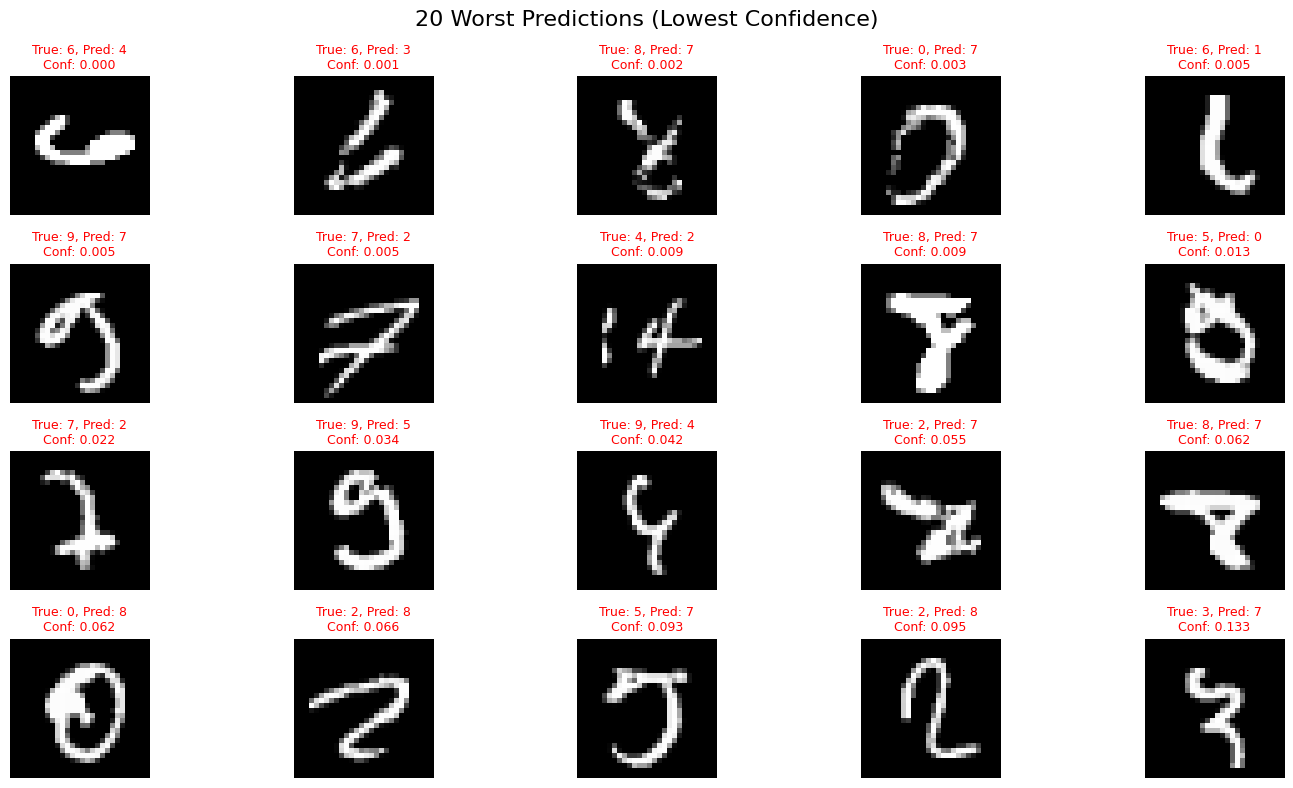

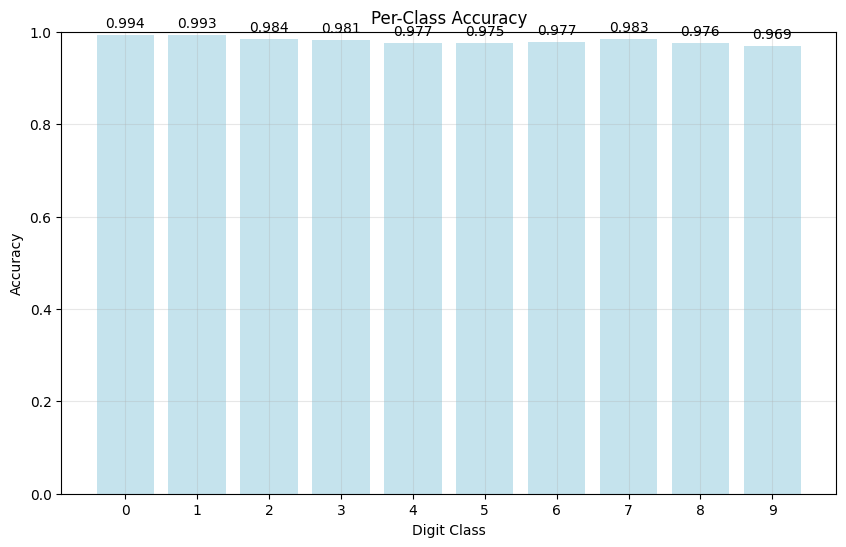

Per-class accuracy:
Digit 0: 0.9939
Digit 1: 0.9930
Digit 2: 0.9845
Digit 3: 0.9812
Digit 4: 0.9766
Digit 5: 0.9753
Digit 6: 0.9770
Digit 7: 0.9835
Digit 8: 0.9764
Digit 9: 0.9693


In [36]:
# Enhanced error analysis
y_pred = model.predict(X_test, verbose=0)
y_pred_labels = [np.argmax(i) for i in y_pred]

# Find misclassified examples
misclassified_idx = np.where(y_test != y_pred_labels)[0]
print(f"Total misclassified: {len(misclassified_idx)} out of {len(y_test)} ({len(misclassified_idx)/len(y_test)*100:.2f}%)")

# Show worst predictions (lowest confidence for correct class)
confidence_scores = []
for i in range(len(y_test)):
    true_class = y_test[i]
    confidence = y_pred[i][true_class]  # Confidence for the true class
    confidence_scores.append(confidence)

confidence_scores = np.array(confidence_scores)
worst_idx = np.argsort(confidence_scores)[:20]  # 20 worst predictions

# Visualize worst predictions
plt.figure(figsize=(15, 8))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    idx = worst_idx[i]
    plt.imshow(X_test[idx], cmap='gray')
    plt.axis('off')
    
    true_label = y_test[idx]
    pred_label = y_pred_labels[idx]
    confidence = confidence_scores[idx]
    
    color = 'red' if true_label != pred_label else 'orange'
    plt.title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.3f}', 
              color=color, fontsize=9)

plt.suptitle('20 Worst Predictions (Lowest Confidence)', fontsize=16)
plt.tight_layout()
plt.show()

# Per-class accuracy
from sklearn.metrics import accuracy_score
class_accuracies = []
for digit in range(10):
    digit_mask = (y_test == digit)
    if np.sum(digit_mask) > 0:
        digit_accuracy = accuracy_score(y_test[digit_mask], np.array(y_pred_labels)[digit_mask])
        class_accuracies.append(digit_accuracy)
    else:
        class_accuracies.append(0)

plt.figure(figsize=(10, 6))
bars = plt.bar(range(10), class_accuracies, color='lightblue', alpha=0.7)
plt.title('Per-Class Accuracy')
plt.xlabel('Digit Class')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
plt.xticks(range(10))

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom')

plt.grid(True, alpha=0.3)
plt.show()

print("Per-class accuracy:")
for i, acc in enumerate(class_accuracies):
    print(f"Digit {i}: {acc:.4f}")

In [37]:
from PIL import Image
import numpy as np

# Load and preprocess the image
img = Image.open("two.webp").convert("L")  # 'L' = grayscale
img = img.resize((28, 28))
arr = np.array(img)
arr = 255 - arr  # Invert colors (MNIST digits are white on black background)
arr = arr / 255.0  # Normalize to 0-1 range


# Reshape for model input - your model uses Flatten layer so it expects (batch_size, 28, 28)
arr_input = arr.reshape(1, 28, 28)  # Shape: (1, 28, 28) - this is correct for your model

# Make prediction
pred = model.predict(arr_input, verbose=0)
digit = np.argmax(pred)
confidence = np.max(pred)


print(f"Predicted digit: {digit}")
print(f"Confidence: {confidence:.3f}")
print(f"All probabilities: {pred[0]}")

Predicted digit: 2
Confidence: 1.000
All probabilities: [1.2215566e-03 1.4639444e-02 9.9999988e-01 9.9559265e-01 2.0047284e-12
 1.5582164e-07 5.1405497e-10 1.2961304e-04 7.5983489e-01 6.8526177e-08]


## Real-World Testing

Testing the model on external images to see how well it generalizes.

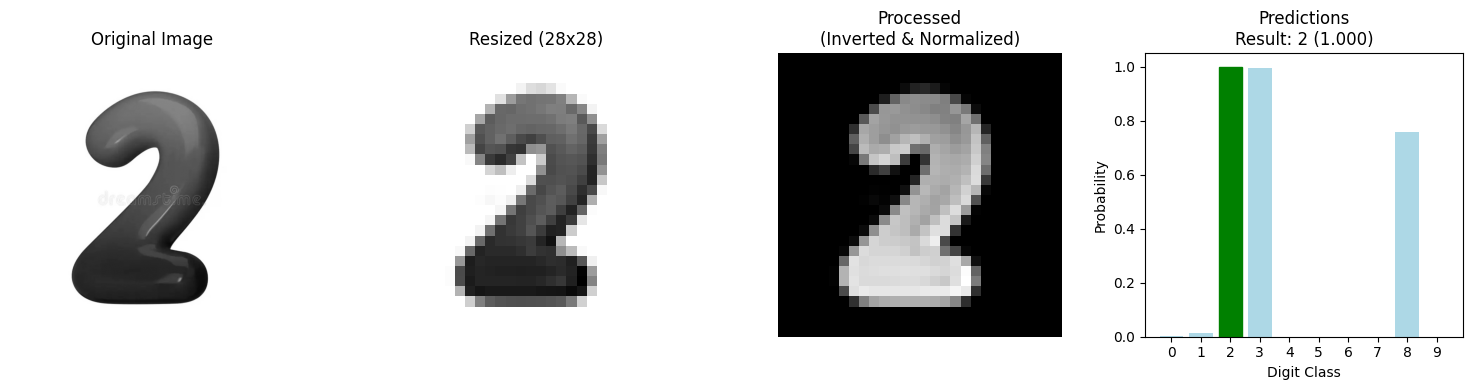


🎯 Prediction: 2
🎪 Confidence: 1.0000
📊 All probabilities: ['0.0012', '0.0146', '1.0000', '0.9956', '0.0000', '0.0000', '0.0000', '0.0001', '0.7598', '0.0000']

📋 Model Summary:
Total parameters: 102,070
Model size: ~0.39 MB (float32)
Architecture: 4 layers
  Layer 1: Flatten - Shape not built yet
  Layer 2: Dense - Shape not built yet
  Layer 3: Dense - Shape not built yet
  Layer 4: Dense - Shape not built yet


In [39]:
# Interactive prediction function for any image
def predict_digit_interactive(image_path_or_array, show_processing=True):
    """
    Predict digit from image file or numpy array
    """
    if isinstance(image_path_or_array, str):
        # Load from file
        img = Image.open(image_path_or_array).convert("L")
        original_img = np.array(img)
    else:
        # Use provided array
        original_img = image_path_or_array
        img = Image.fromarray(original_img.astype(np.uint8))
    
    # Preprocess
    img_resized = img.resize((28, 28))
    arr = np.array(img_resized)
    arr = 255 - arr  # Invert if needed
    arr = arr / 255.0
    
    if show_processing:
        plt.figure(figsize=(15, 4))
        
        # Original image
        plt.subplot(1, 4, 1)
        plt.imshow(original_img, cmap='gray')
        plt.title('Original Image')
        plt.axis('off')
        
        # Resized image
        plt.subplot(1, 4, 2)
        plt.imshow(img_resized, cmap='gray')
        plt.title('Resized (28x28)')
        plt.axis('off')
        
        # Processed image
        plt.subplot(1, 4, 3)
        plt.imshow(arr, cmap='gray')
        plt.title('Processed\n(Inverted & Normalized)')
        plt.axis('off')
    
    # Predict
    arr_input = arr.reshape(1, 28, 28)
    pred = model.predict(arr_input, verbose=0)
    digit = np.argmax(pred)
    confidence = np.max(pred)
    
    if show_processing:
        # Prediction probabilities
        plt.subplot(1, 4, 4)
        bars = plt.bar(range(10), pred[0], color=['red' if i == digit else 'lightblue' for i in range(10)])
        plt.title(f'Predictions\nResult: {digit} ({confidence:.3f})')
        plt.xlabel('Digit Class')
        plt.ylabel('Probability')
        plt.xticks(range(10))
        
        # Highlight the predicted digit
        bars[digit].set_color('green')
        
        plt.tight_layout()
        plt.show()
    
    return digit, confidence, pred[0]

# Example usage
try:
    digit, conf, all_probs = predict_digit_interactive("two.webp")
    print(f"\n🎯 Prediction: {digit}")
    print(f"🎪 Confidence: {conf:.4f}")
    print(f"📊 All probabilities: {[f'{p:.4f}' for p in all_probs]}")
except FileNotFoundError:
    print("Image file 'two.webp' not found. Please ensure the file exists in the current directory.")
    print("You can test with any image file by calling: predict_digit_interactive('your_image.png')")

# Model summary
print(f"\n📋 Model Summary:")
print(f"Total parameters: {model.count_params():,}")
print(f"Model size: ~{model.count_params() * 4 / 1024 / 1024:.2f} MB (float32)")
print(f"Architecture: {len(model.layers)} layers")
for i, layer in enumerate(model.layers):
    try:
        output_shape = layer.output_shape
        print(f"  Layer {i+1}: {layer.__class__.__name__} - {output_shape}")
    except AttributeError:
        # For layers that don't have output_shape defined yet
        print(f"  Layer {i+1}: {layer.__class__.__name__} - Shape not built yet")
    except Exception:
        # Fallback for any other issues
        print(f"  Layer {i+1}: {layer.__class__.__name__}")